<a href="https://colab.research.google.com/github/sandeepkhadk/Next_Word_Prediction_With_Federated_learning/blob/main/gru_next_word_prediction_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRU Next-Word Prediction — Colab Free-Tier Optimized
**Optimizations applied:**
- `MAX_VOCAB = 8000` (was 20000) → smaller embedding, faster softmax
- `MAX_SEQ_LEN = 20` (was 50) → 60 % less memory per sample
- `EMBED_DIM = 64` (was 100) → lighter embedding matrix
- `GRU_UNITS = 64` (was 128) → 4× fewer GRU parameters
- `BATCH_SIZE = 512` with `tf.data` prefetch → full GPU utilisation
- `EPOCHS = 5` + EarlyStopping patience=2 → stops early if converged
- Per-subreddit sample cap of **2000 rows** → 5-min wall-clock target
- Sparse-categorical cross-entropy unchanged (correct for this task)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = '/content/drive/MyDrive/Next_word_prediction'
os.makedirs(BASE_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
import re, pickle
import numpy as np
import pandas as pd
import tensorflow as tf

# ── GPU memory growth ─────────────────────────────────────────────────────────
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

# ════════════════════════════════════════════════════════════════════════════
# HYPER-PARAMETERS  (tuned for Colab Free-Tier T4, ≤5-min training target)
# ════════════════════════════════════════════════════════════════════════════
MAX_VOCAB    = 8_000   # was 20 000 → 60 % smaller embedding + softmax
MAX_SEQ_LEN  = 20      # was 50    → 60 % less RAM per sample
EMBED_DIM    = 64      # was 100   → lighter embedding matrix
GRU_UNITS    = 64      # was 128   → 4× fewer GRU params
DROPOUT      = 0.2
BATCH_SIZE   = 512     # larger batch → better GPU utilisation
EPOCHS       = 5       # EarlyStopping will exit even earlier if converged

# Cap rows per subreddit — keeps dataset < ~500 k sequences
ROWS_PER_SUB = 2_000   # ← increase to 5 000 if you want higher accuracy
                        #   and have a Pro / Pro+ runtime

KEEP_SUBREDDITS = [
    'gaming', 'politics', 'news', 'movies', 'funny',
    'AskReddit', 'nba', 'unpopularopinion', 'memes', 'Animemes'
]
TEXT_COL = 'body'

TOKENIZER_PATH = f'{BASE_DIR}/tokenizer_opt.pkl'
ARRAYS_PATH    = f'{BASE_DIR}/xy_arrays_opt.npz'

print('Hyper-parameters set.')
print(f'  vocab={MAX_VOCAB}  seq_len={MAX_SEQ_LEN}  '
      f'embed={EMBED_DIM}  gru={GRU_UNITS}  batch={BATCH_SIZE}')


Hyper-parameters set.
  vocab=8000  seq_len=20  embed=64  gru=64  batch=512


## 2. Load & Preprocess Data


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

if os.path.exists(TOKENIZER_PATH) and os.path.exists(ARRAYS_PATH):
    print('Loading cached tokenizer and arrays...')
    with open(TOKENIZER_PATH, 'rb') as f:
        tokenizer = pickle.load(f)
    data = np.load(ARRAYS_PATH)
    X, y = data['X'], data['y']
    vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
    print(f'X: {X.shape}  y: {y.shape}  vocab_size: {vocab_size}')
else:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    csv_path = f'{BASE_DIR}/kaggle_RC_2019-05.csv'
    df = pd.read_csv(csv_path)
    df[TEXT_COL] = df[TEXT_COL].apply(clean_text)
    df = df[df[TEXT_COL].str.split().str.len() >= 3]
    df = df[df['subreddit'].isin(KEEP_SUBREDDITS)].reset_index(drop=True)

    # ── Cap rows per subreddit to control dataset size ────────────────────
    df = (
        df.groupby('subreddit', group_keys=False)
          .apply(lambda g: g.sample(min(len(g), ROWS_PER_SUB), random_state=42))
          .reset_index(drop=True)
    )
    print(f'Capped df: {df.shape}  (max {ROWS_PER_SUB} rows/subreddit)')

    tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(df[TEXT_COL])
    vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

    X_list, y_list = [], []
    for text in df[TEXT_COL]:
        tokens = tokenizer.texts_to_sequences([text])[0][:MAX_SEQ_LEN]
        for i in range(1, len(tokens)):
            X_list.append(tokens[:i])
            y_list.append(tokens[i])

    X = pad_sequences(X_list, maxlen=MAX_SEQ_LEN, padding='pre')
    y = np.array(y_list, dtype=np.int32)

    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tokenizer, f)
    np.savez_compressed(ARRAYS_PATH, X=X, y=y)
    print(f'Saved. X: {X.shape}  y: {y.shape}  vocab_size: {vocab_size}')


Loading cached tokenizer and arrays...
X: (250963, 20)  y: (250963,)  vocab_size: 8000


## 3. Train / Val Split + tf.data Pipeline


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')

# ── tf.data with prefetch — maximises GPU occupancy ──────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(20_000, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


Train: (225866, 20)  Val: (25097, 20)


## 4. Build GRU Model


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding, GRU, Dense, Dropout, LayerNormalization
)

def build_gru_model(vocab_size, embed_dim, gru_units, dropout):
    model = Sequential([
        # No input_length → avoids deprecation warning in Keras 3
        Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding'),
        GRU(gru_units, return_sequences=True, reset_after=False, name='gru_1'),
        LayerNormalization(name='ln_1'),
        Dropout(dropout, name='drop_1'),
        GRU(gru_units, reset_after=False, name='gru_2'),
        LayerNormalization(name='ln_2'),
        Dropout(dropout, name='drop_2'),
        Dense(vocab_size, activation='softmax', name='output'),
    ], name='gru_next_word')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

model = build_gru_model(vocab_size, EMBED_DIM, GRU_UNITS, DROPOUT)
model(np.zeros((1, MAX_SEQ_LEN), dtype=np.int32))  # build weights
model.summary()


Model: "gru_next_word"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 20, 64)            │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (1, 20, 64)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_1 (LayerNormalization)       │ (1, 20, 64)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (1, 20, 64)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (1, 64)                │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_2 (LayerNormalization)       │ (1, 64)                │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 8000)              │       520,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,081,792 (4.13 MB)

 Trainable params: 1,081,792 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Callbacks & Training


In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

CKPT_PATH = f'{BASE_DIR}/gru_best_opt.keras'

callbacks = [
    ModelCheckpoint(
        CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=2,             # stop fast if no improvement
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)
print('Training complete.')


Epoch 1/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0593 - loss: 6.8150
Epoch 1: val_accuracy improved from None to 0.13221, saving model to /content/drive/MyDrive/Next_word_prediction/gru_best_opt.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Next_word_prediction/gru_best_opt.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.0816 - loss: 6.3536 - val_accuracy: 0.1322 - val_loss: 5.7249 - learning_rate: 0.0020
Epoch 2/5
438/442 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1294 - loss: 5.7407
Epoch 2: val_accuracy improved from 0.13221 to 0.15101, saving model to /content/drive/MyDrive/Next_word_prediction/gru_best_opt.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Next_word_prediction/gru_best_opt.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1351 - loss: 5.6595 - val_accuracy: 0.1510 - val_loss: 5.5049 - learning_rate: 0.0020
Epoch 3/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1490 - loss: 5

## 6. Training Curves


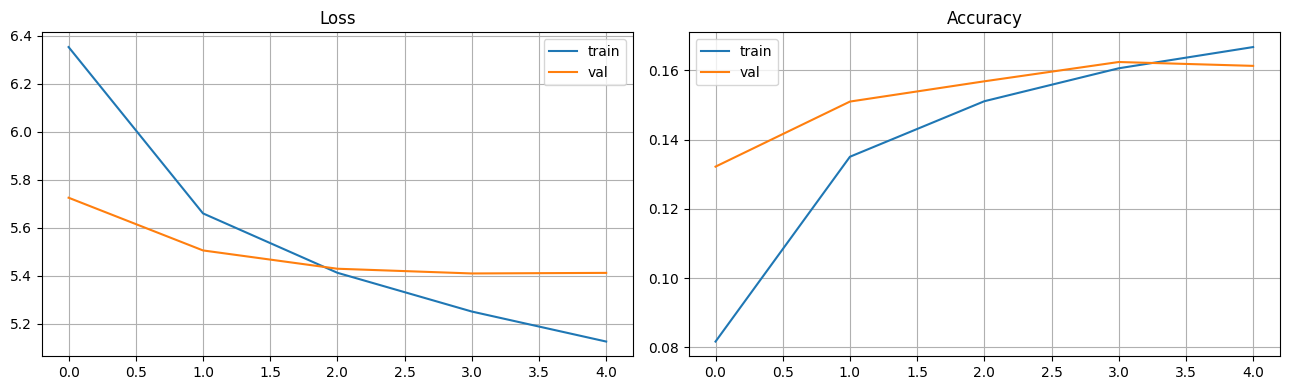

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/training_curves_opt.png', dpi=150)
plt.show()


## 7. Evaluation (Perplexity + Top-5 Accuracy)


In [ ]:
import math

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
perplexity = math.exp(min(val_loss, 20))

print(f'Val  Loss       : {val_loss:.4f}')
print(f'Val  Accuracy   : {val_acc:.4f}')
print(f'Val  Perplexity : {perplexity:.2f}')

# Top-5 accuracy on a random subset
SAMPLE = 20_000
idx    = np.random.choice(len(X_val), min(SAMPLE, len(X_val)), replace=False)
preds  = model.predict(X_val[idx], batch_size=BATCH_SIZE, verbose=0)
top5   = np.argsort(preds, axis=-1)[:, -5:]
top5_acc = np.mean([y_val[idx[i]] in top5[i] for i in range(len(idx))])
print(f'Top-5 Accuracy  : {top5_acc:.4f}')


Val  Loss       : 5.4089
Val  Accuracy   : 0.1624
Val  Perplexity : 223.38
Top-5 Accuracy  : 0.3209


## 8. Inference


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences as pad_seq

def predict_next_words(seed_text, model, tokenizer, max_seq_len,
                        top_k=5, num_words=1):
    reverse_index = {v: k for k, v in tokenizer.word_index.items()}
    text = seed_text.lower()
    for _ in range(num_words):
        tokens = tokenizer.texts_to_sequences([text])[0]
        padded = pad_seq([tokens], maxlen=max_seq_len, padding='pre')
        probs  = model.predict(padded, verbose=0)[0]
        top_idx = np.argsort(probs)[-top_k:][::-1]
        if num_words == 1:
            return [(reverse_index.get(i, '<UNK>'), float(probs[i])) for i in top_idx]
        next_word = reverse_index.get(top_idx[0], '<UNK>')
        text += ' ' + next_word
    return text

seeds = ['i think the game is', 'the news today is about', 'What the  ']
for seed in seeds:
    print(f'Seed: "{seed}"')
    for word, prob in predict_next_words(seed, model, tokenizer, MAX_SEQ_LEN, top_k=5):
        print(f'  {word:<20} {prob:.4f}')
    print()

print('Generated:', predict_next_words('the best way to play',
      model, tokenizer, MAX_SEQ_LEN, top_k=5, num_words=10))


Seed: "i think the game is"
  a                    0.0910
  the                  0.0600
  <OOV>                0.0306
  gonna                0.0261
  that                 0.0240

Seed: "the news today is about"
  the                  0.2525
  <OOV>                0.0839
  that                 0.0614
  a                    0.0367
  it                   0.0278

Seed: "What the  "
  fuck                 0.0989
  <OOV>                0.0564
  only                 0.0159
  hell                 0.0152
  people               0.0128

Generated: the best way to play the <OOV> of the <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>


## 9. Save Final Model & Tokenizer


In [ ]:
model.save(f'{BASE_DIR}/gru_final_opt.keras')
with open(f'{BASE_DIR}/tokenizer_opt.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Saved: gru_final_opt.keras  +  tokenizer_opt.pkl')


Saved: gru_final_opt.keras  +  tokenizer_opt.pkl


## **11. XAI**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Gradient-based explanation
# -----------------------------
def explain_prediction(model, tokenizer, text, max_len):
    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = seq[-max_len:]
    seq = tf.keras.preprocessing.sequence.pad_sequences([seq], maxlen=max_len)
    seq = tf.constant(seq)

    with tf.GradientTape() as tape:
        # Get embedding layer output
        embedding_layer = model.get_layer("embedding")
        embeddings = embedding_layer(seq)
        tape.watch(embeddings)

        x = embeddings
        for layer in model.layers[1:]:
            x = layer(x)
        predictions = x

        # Predicted word
        predicted_index = tf.argmax(predictions[0])
        predicted_prob = predictions[:, predicted_index]

    # Compute gradients
    gradients = tape.gradient(predicted_prob, embeddings)
    importance = tf.reduce_sum(tf.abs(gradients), axis=-1).numpy()[0]

    words = text.split()
    importance = importance[-len(words):]  # match words
    return words, importance

# -----------------------------
# Plot importance
# -----------------------------
def plot_importance(words, importance):
    plt.figure(figsize=(8,4))
    plt.bar(words, importance, color='skyblue')
    plt.title("Word Importance for Next Word Prediction")
    plt.xticks(rotation=45)
    plt.show()

# -----------------------------
# Combined prediction + explanation
# -----------------------------
def predict_and_explain(model, tokenizer, text, max_len, top_k=5):
    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([text])[0][-max_len:]
    seq = tf.keras.preprocessing.sequence.pad_sequences([seq], maxlen=max_len)

    # Model prediction
    preds = model.predict(seq, verbose=0)[0]
    top_indices = np.argsort(preds)[-top_k:][::-1]

    print("🔹 Top Predictions:")
    for i in top_indices:
        print(tokenizer.index_word.get(i, "<UNK>"), f"{preds[i]:.4f}")

    # Gradient-based explanation
    words, importance = explain_prediction(model, tokenizer, text, max_len)
    print("\n🔹 Word Importance:")
    for w, score in zip(words, importance):
        print(f"{w} → {score:.4f}")

    # Plot
    plot_importance(words, importance)

🔹 Top Predictions:
<OOV> 0.0376
first 0.0240
game 0.0229
movie 0.0222
same 0.0176

🔹 Word Importance:
I → 0.3631
love → 0.3593
playing → 0.3453
football → 0.5763
in → 0.6173
the → 0.6491


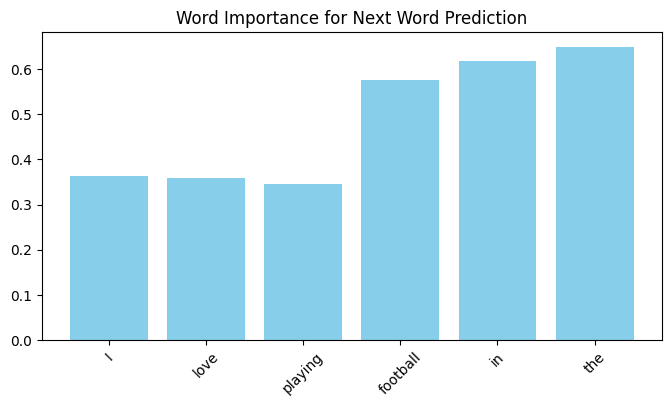

In [ ]:
input_text = "I love playing football in the"
predict_and_explain(model, tokenizer, input_text, MAX_SEQ_LEN, top_k=5)